**TUGAS MANDIRI**

**A. Membangun Struktur Direktori HDFS**

Perintah berikut digunakan untuk membuat direktori baru.

In [ ]:
!hdfs dfs -mkdir -p /user/deb/ecommerce/raw
!hdfs dfs -mkdir -p /user/deb/ecommerce/processed

Perintah berikut digunakan untuk membuktikan bahwa direktori berhasil dibuat dengan menampilkan hasilnya.

In [2]:
!hdfs dfs -ls /user/deb/ecommerce

Found 2 items
drwxr-xr-x   - deb supergroup          0 2026-09-09 01:16 /user/deb/ecommerce/processed
drwxr-xr-x   - deb supergroup          0 2026-09-09 01:16 /user/deb/ecommerce/raw


**B. Mengunggah Data Mentah ke HDFS**

Perintah berikut digunakan untuk mengunggah file CSV ke direktori yang sudah dibuat sebelumnya.

In [3]:
!hdfs dfs -put transaksi_magelang.csv transaksi_yogyakarta.csv transaksi_semarang.csv /user/deb/ecommerce/raw

Perintah berikut digunakan untuk menampilkan isi direktori dan ukurannya yang menunjukkan berkas berhasil di unggah.

In [9]:
!hdfs dfs -ls -h /user/deb/ecommerce/raw

Found 3 items
-rw-r--r--   1 deb supergroup     12.0 K 2026-09-09 03:35 /user/deb/ecommerce/raw/transaksi_magelang.csv
-rw-r--r--   1 deb supergroup     11.9 K 2026-09-09 03:35 /user/deb/ecommerce/raw/transaksi_semarang.csv
-rw-r--r--   1 deb supergroup     12.4 K 2026-09-09 03:35 /user/deb/ecommerce/raw/transaksi_yogyakarta.csv


**C. Membaca Kembali dan Menggabungkan Data dari HDFS**

Perintah berikut digunakan untuk membaca file HDFS, menggabungkan menjadi satu DataFrame, serta menampilkan hasil gabungan berupa transaksi dari ketiga kota.

In [12]:
import pandas as pd
import io
import subprocess

files = ["transaksi_magelang.csv", "transaksi_yogyakarta.csv", "transaksi_semarang.csv"]
dfs = []

for file in files:
    path = f"/user/deb/ecommerce/raw/{file}"
    cmd = f"hdfs dfs -cat {path}"
    output = subprocess.check_output(cmd, shell=True)

    df_temp = pd.read_csv(io.BytesIO(output))
    dfs.append(df_temp)

df_gabung = pd.concat(dfs, ignore_index=True)

print("Jumlah transaksi per kota :")
print(df_gabung["kota"].value_counts())

Jumlah transaksi per kota :
kota
Magelang      200
Yogyakarta    200
Semarang      200
Name: count, dtype: int64


**D. Mengolah dan Download Hasil ke Direktori processed**

Perintah berikut digunakan untuk menambahkan kolom total_pendapatan, membuat tabel ringkasan, menyimpan hasil ke CSV baru, lalu diunggah di HDFS folder processed.

In [13]:
df_gabung['total_pendapatan'] = df_gabung['unit_terjual'] * df_gabung['harga_satuan']

df_ringkasan = df_gabung.groupby(['kota', 'kategori'])['total_pendapatan'].sum().reset_index()

print('Tabel ringkasan total pendapatan per kota dan per kategori')
print(df_ringkasan)

df_gabung.to_csv('data_gabungan_bersih.csv', index=False)
df_ringkasan.to_csv('ringkasan_kota_kategori.csv', index=False)

!hdfs dfs -put data_gabungan_bersih.csv /user/deb/ecommerce/processed/
!hdfs dfs -put ringkasan_kota_kategori.csv /user/deb/ecommerce/processed/

!hdfs dfs -ls /user/deb/ecommerce/processed/

Tabel ringkasan total pendapatan per kota dan per kategori
          kota                kategori  total_pendapatan
0     Magelang              Elektronik          18775000
1     Magelang                 Fashion          27750000
2     Magelang  Kesehatan & Kecantikan          17375000
3     Magelang       Makanan & Minuman          17525000
4     Magelang            Rumah Tangga          12200000
5     Semarang              Elektronik          21425000
6     Semarang                 Fashion          26425000
7     Semarang  Kesehatan & Kecantikan          13525000
8     Semarang       Makanan & Minuman          19750000
9     Semarang            Rumah Tangga          10975000
10  Yogyakarta              Elektronik          18500000
11  Yogyakarta                 Fashion          26625000
12  Yogyakarta  Kesehatan & Kecantikan          19700000
13  Yogyakarta       Makanan & Minuman          15175000
14  Yogyakarta            Rumah Tangga          17275000
Found 2 items
-rw-r--r--   1 

**E. Dokumentasi dan Refleksi**

Gambar berikut merupakan tampilan NameNode Web UI yang menunjukkan folder ecommerce beserta isinya.

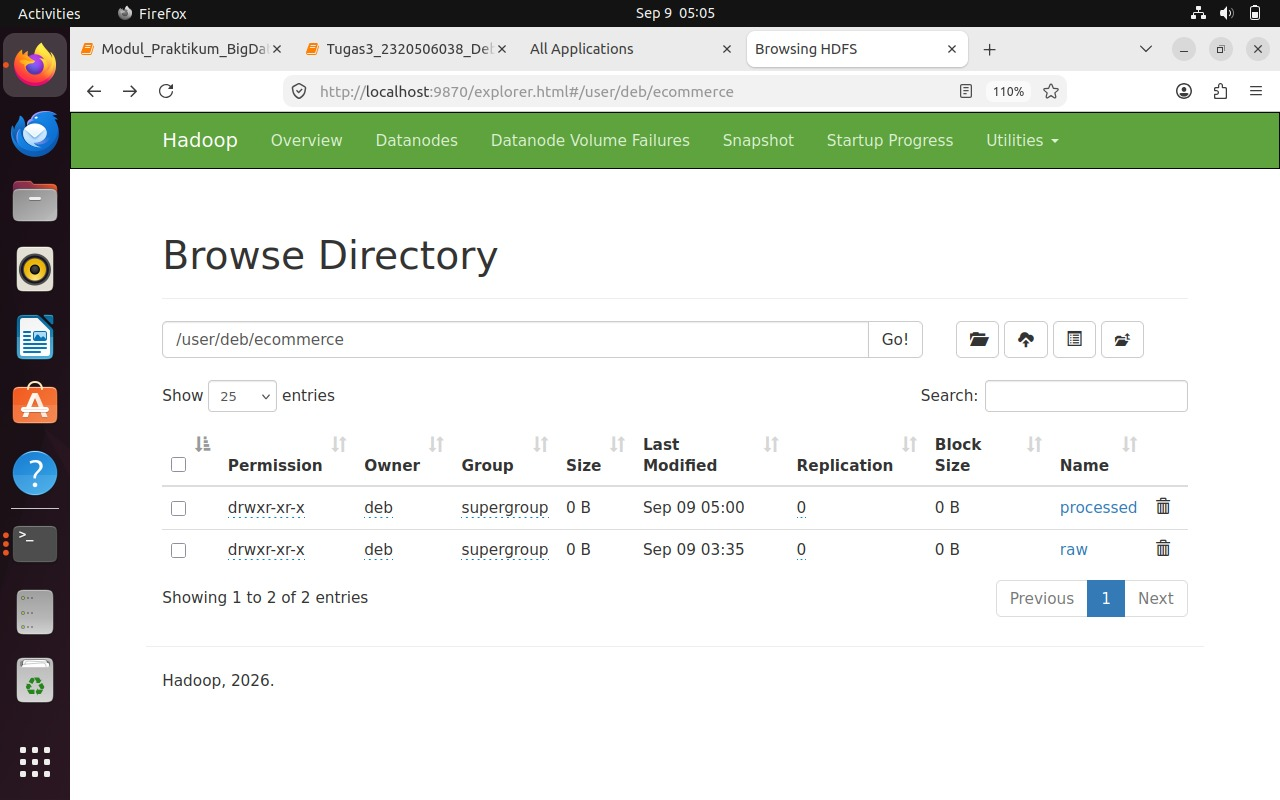
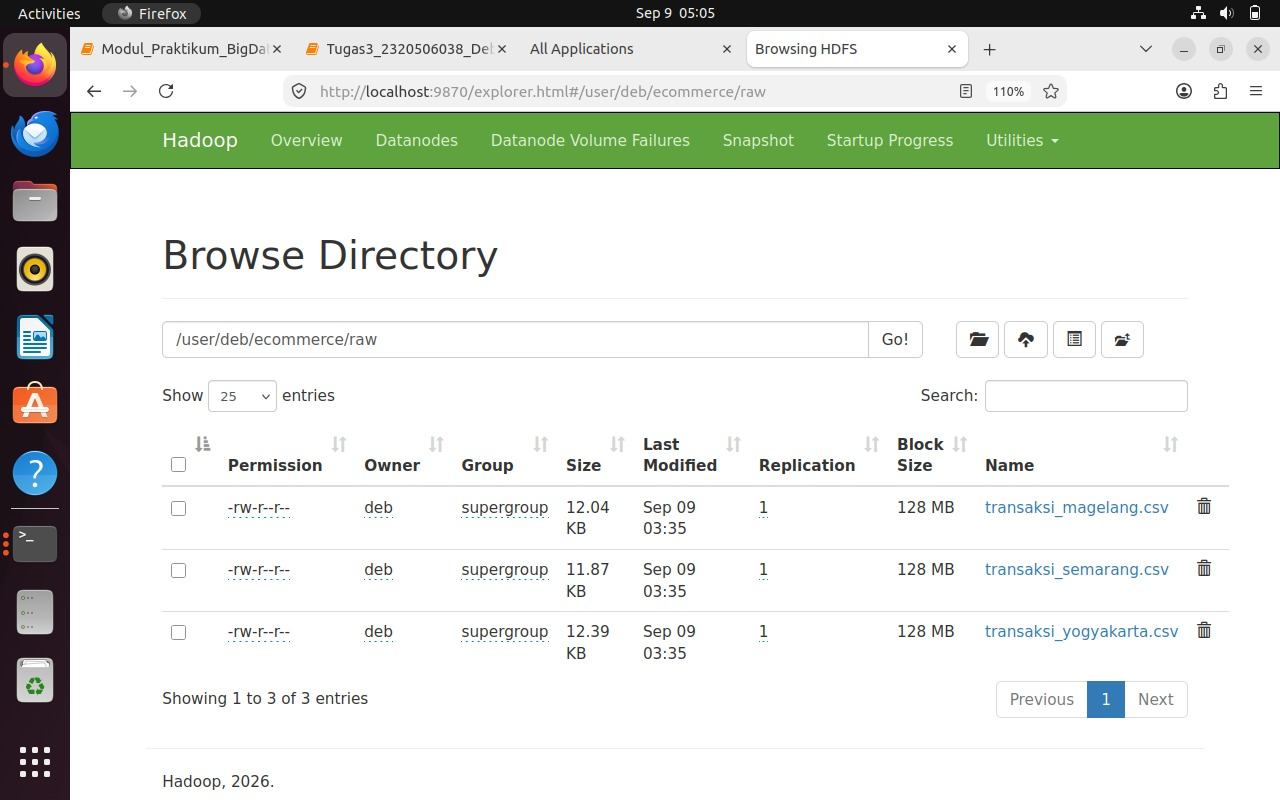
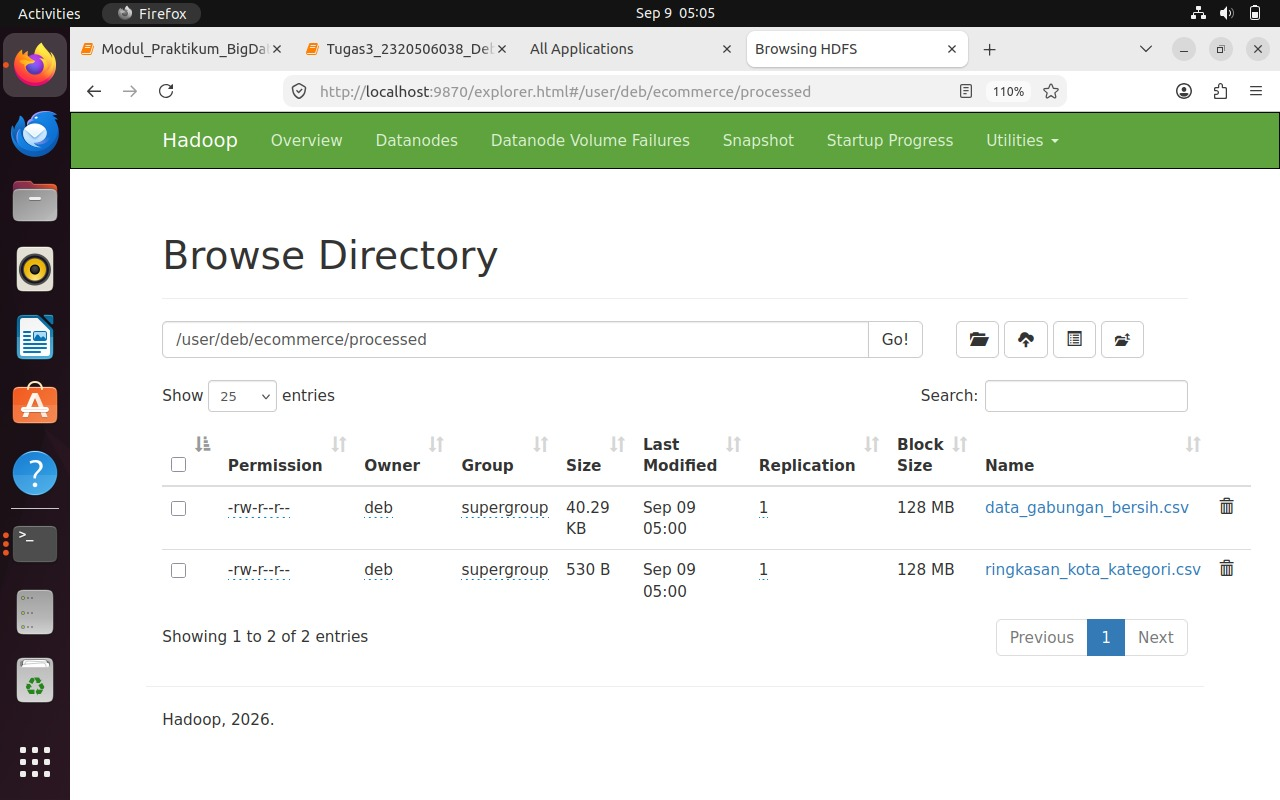

Apa keuntungan menyimpan data mentah (raw) terpisah dari data olahan (processed) di HDFS, dibandingkan menyimpan semuanya bercampur dalam satu folder?

**Jawaban :** Keuntungan memisah penyimpanan kedua data tersebut adalah agar kita masih dapat memiliki sumber data utama dari data mentah sebagai dokumen asli. Jika algoritma yang digunakan untuk memproses data mentah tersebut salah, kita tidak perlu khawatir akan kehilangan data asli karena data mentah dan data olahan disimpan terpisah. Sehingga kita bisa mengulang proses pengolahan data menggunakan algoritma lain menggunakan data mentah tersebut. Selain itu, data mentah juga masih mengandung informasi sensitif, data kotor, atau format yang belum divalidasi. Sehingga ketika data tersebut disimpan terpisah, kita dapat membedakan siapa yang dapat mengakses data mentah dan siapa saja yang dapat mengakses data olahan. Jika data analys mengakses data mentah, hasil analisis kemungkinan akan menjadi tidak akurat, menyebabkan penurunan sistem, serta berisiko terjadi kebocoran data. Kemudian, jika data mentah dan data olahan dijadikan satu folder, akan menyebabkan sistem tidak berjalan dengan efisien, karena sistem akan memindai seluruh folder sehingga dapat membuang waktu dan memori. 